In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

IMG_DIR = "images"

def show(img, title="", figsize=(5, 5), cmap=None):
    """Small helper to display a BGR (OpenCV) or grayscale image with matplotlib."""
    plt.figure(figsize=figsize)
    if img.ndim == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_pair(img1, img2, t1="Before", t2="After", figsize=(10, 5)):
    fig, ax = plt.subplots(1, 2, figsize=figsize)
    for a, im, t in zip(ax, (img1, img2), (t1, t2)):
        if im.ndim == 2:
            a.imshow(im, cmap="gray")
        else:
            a.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        a.set_title(t)
        a.axis("off")
    plt.tight_layout()
    plt.show()


## Task 1 — The Tiny Fingerprint (Linear · Scale)


Scaling matrix S =
 [[3. 0.]
 [0. 3.]]

Full 2x3 affine (scale + re-center) matrix:
 [[   3.    0. -387.]
 [   0.    3. -516.]]


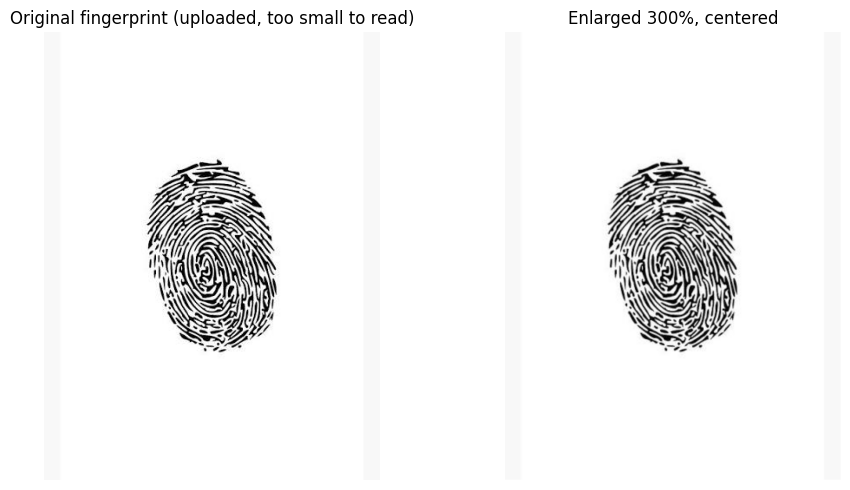

In [2]:
img = cv2.imread(f"{IMG_DIR}/task1_tiny_fingerprint_user.png")  # your uploaded fingerprint
h, w = img.shape[:2]
cx, cy = w / 2, h / 2

# --- 1. Manually build the 2x2 linear scaling matrix ---
sx, sy = 3.0, 3.0
S = np.array([[sx, 0],
              [0, sy]], dtype=np.float64)
print("Scaling matrix S =\n", S)

# --- 2. Keep the image centered: scale about the center, not the origin ---
# p' = S(p - c) + c  =>  p' = S*p + (c - S*c)
c = np.array([cx, cy])
t = c - S @ c   # translation needed to re-center after scaling

# Build the 2x3 affine matrix OpenCV expects: [S | t]
M = np.hstack([S, t.reshape(2, 1)])
print("\nFull 2x3 affine (scale + re-center) matrix:\n", M)

# --- 3. Warp: output canvas must grow too, or we clip the 300%-bigger print ---
out_w, out_h = int(w * sx), int(h * sy)
# shift so the enlarged, centered fingerprint lands in the middle of the new canvas
M[:, 2] += np.array([(out_w - w) / 2, (out_h - h) / 2])

# white border fill to match this fingerprint image's white background
enlarged = cv2.warpAffine(img, M, (out_w, out_h), borderValue=(255, 255, 255))

show_pair(img, enlarged, "Original fingerprint (uploaded, too small to read)", "Enlarged 300%, centered")


## Task 2 — The Dizzy Satellite (Linear · Rotation)

Rotation matrix R =
 [[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]

Original size: 560x560  ->  New (non-clipping) size: 791x791


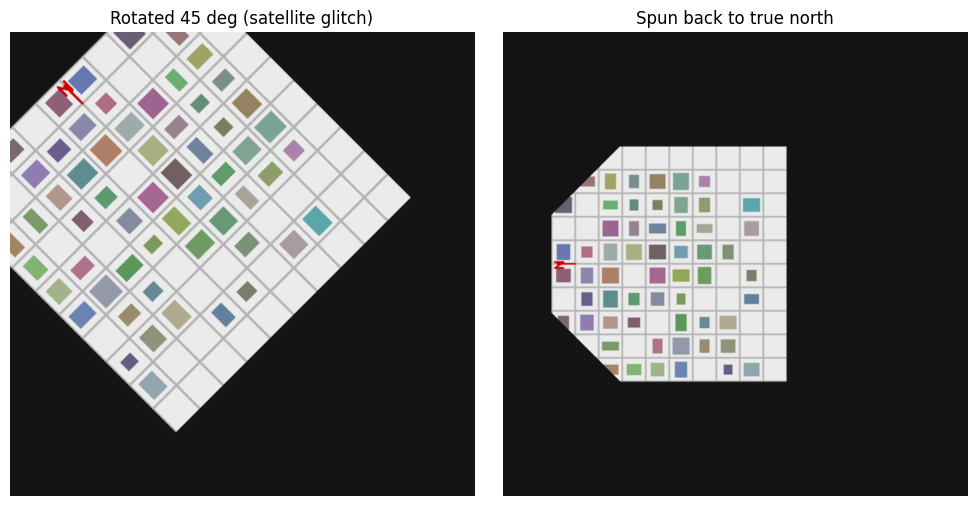

In [3]:
img = cv2.imread(f"{IMG_DIR}/task2_dizzy_satellite.png")
h, w = img.shape[:2]
cx, cy = w / 2, h / 2

# --- 1. Manually build the 2x2 rotation matrix (undo the +45 deg spin) ---
theta = np.deg2rad(-45)   # negative: rotate back
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
print("Rotation matrix R =\n", R)

# --- 2. Manually compute the new, non-clipping canvas size ---
new_w = int(abs(w * np.cos(theta)) + abs(h * np.sin(theta)))
new_h = int(abs(w * np.sin(theta)) + abs(h * np.cos(theta)))
print(f"\nOriginal size: {w}x{h}  ->  New (non-clipping) size: {new_w}x{new_h}")

# --- 3. Build full 2x3 affine matrix: rotate about center, then re-center ---
c = np.array([cx, cy])
t = c - R @ c
M = np.hstack([R, t.reshape(2, 1)])
# shift into the middle of the LARGER canvas
M[:, 2] += np.array([(new_w - w) / 2, (new_h - h) / 2])

corrected = cv2.warpAffine(img, M, (new_w, new_h), borderValue=(20, 20, 20))

show_pair(img, corrected, "Rotated 45 deg (satellite glitch)", "Spun back to true north")


## Task 3 — The Fast Train Barcode (Linear · Shear)

**Scenario:** A scanner photographed a barcode on a fast-moving train; the
image looks slanted to the right.

**Task:** Construct a 2×2 shear matrix to push pixels horizontally and
straighten the slanted lines back into a perfect rectangle.

**Math:** A horizontal shear (pixels shift right proportionally to their
`y` value) is undone with the *inverse* shear factor:

$$
Sh = \begin{bmatrix} 1 & -k \\ 0 & 1 \end{bmatrix},
\qquad x' = x - k y,\quad y' = y
$$


Shear matrix Sh =
 [[ 1.  -0.5]
 [ 0.   1. ]]

Full 2x3 affine matrix:
 [[  1.   -0.5 100. ]
 [  0.    1.    0. ]]


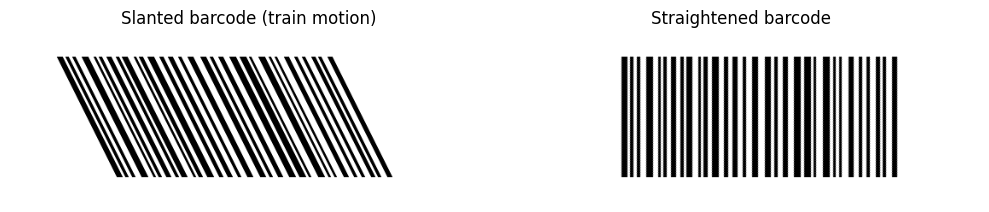

In [4]:
img = cv2.imread(f"{IMG_DIR}/task3_slanted_barcode.png")
h, w = img.shape[:2]

# The scan applied a forward shear of k = 0.5 (pixels pushed right as y grows).
# To fix it we apply the INVERSE shear: k_fix = -0.5
k_fix = -0.5

# --- 1. Manually build the 2x2 shear matrix ---
Sh = np.array([[1, k_fix],
               [0, 1]], dtype=np.float64)
print("Shear matrix Sh =\n", Sh)

# --- 2. Build the 2x3 affine matrix (no re-centering needed for a pure shear
#         correction here, but we add a horizontal offset so the corrected
#         barcode doesn't get pushed off the left edge of the canvas) ---
t = np.array([0.5 * h, 0])   # compensate for the leftward shift shear-fix causes
M = np.hstack([Sh, t.reshape(2, 1)])
print("\nFull 2x3 affine matrix:\n", M)

straightened = cv2.warpAffine(img, M, (w, h), borderValue=(255, 255, 255))

show_pair(img, straightened, "Slanted barcode (train motion)", "Straightened barcode")


## Task 4 — The Hidden Treasure Map (Affine · Translation)


3x3 homogeneous translation matrix T =
 [[  1.   0. 150.]
 [  0.   1.  80.]
 [  0.   0.   1.]]


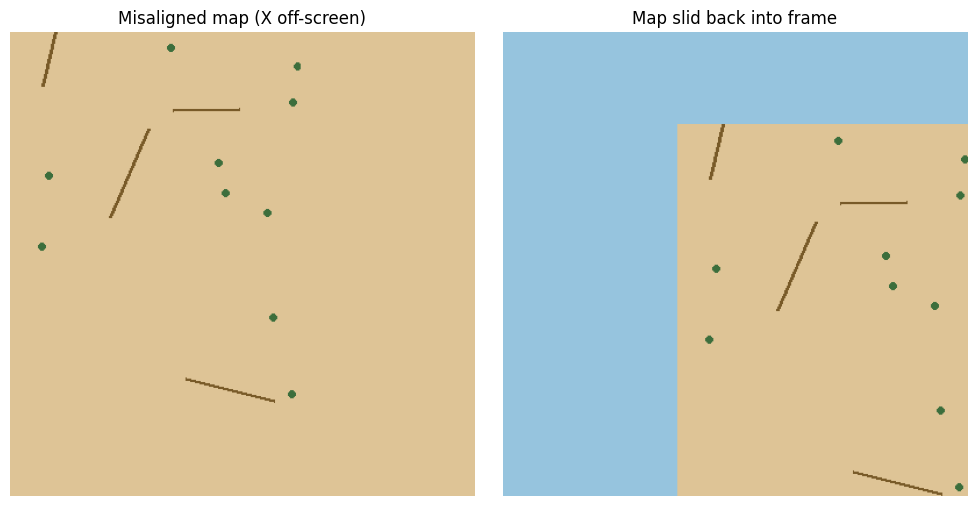

In [5]:
img = cv2.imread(f"{IMG_DIR}/task4_treasure_map_misaligned.png")
h, w = img.shape[:2]

# --- 1. Build the 3x3 homogeneous translation matrix ---
tx, ty = 150, 80   # undo the (-150, -80) misalignment
T = np.array([[1, 0, tx],
              [0, 1, ty],
              [0, 0, 1]], dtype=np.float64)
print("3x3 homogeneous translation matrix T =\n", T)

# --- 2. Apply it to every pixel (as a 2x3 matrix for cv2.warpAffine,
#         which is just T with the last row dropped) ---
M = T[:2, :]
restored_map = cv2.warpAffine(img, M, (w, h), borderValue=(222, 196, 150))

show_pair(img, restored_map, "Misaligned map (X off-screen)", "Map slid back into frame")


## Task 5 — The Robot's Assembly Line (Rigid Transformation)

3x3 Rigid transformation matrix (Rotation + Translation) =
 [[   0.81915204    0.57357644 -123.5905583 ]
 [  -0.57357644    0.81915204  193.4643599 ]
 [   0.            0.            1.        ]]


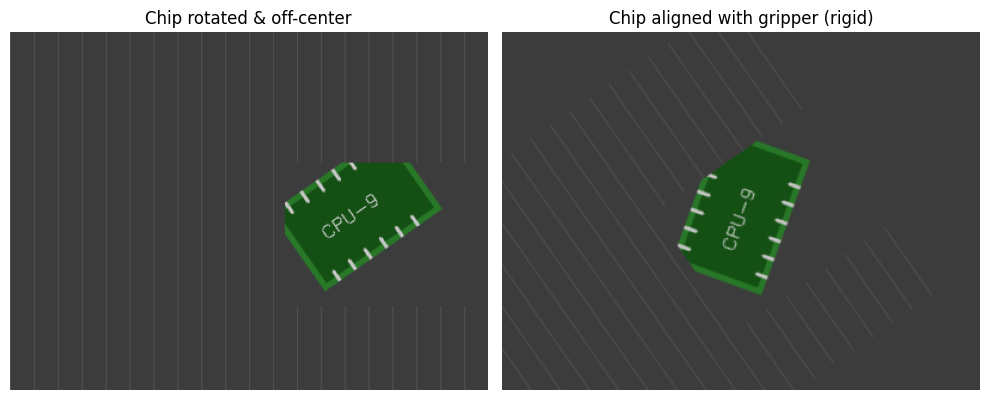

In [6]:
img = cv2.imread(f"{IMG_DIR}/task5_robot_assembly_chip.png")
h, w = img.shape[:2]

# The chip on the belt is rotated ~35 deg and centered near (290, 150)
# (it should end up centered on the gripper target at (200, 150)).
chip_center = np.array([290, 150])
gripper_target = np.array([200, 150])

theta = np.deg2rad(-35)   # rotate the chip back to axis-aligned
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

# translation = where we want it to end up, minus where the rotation
# (applied about the chip's own center) leaves it
t = gripper_target - R @ chip_center

# --- Combine Rotation + Translation into ONE 3x3 rigid matrix ---
M_rigid = np.array([[R[0, 0], R[0, 1], t[0]],
                     [R[1, 0], R[1, 1], t[1]],
                     [0,        0,       1]])
print("3x3 Rigid transformation matrix (Rotation + Translation) =\n", M_rigid)

aligned = cv2.warpAffine(img, M_rigid[:2, :], (w, h), borderValue=(60, 60, 60))

show_pair(img, aligned, "Chip rotated & off-center", "Chip aligned with gripper (rigid)")


## Task 6 — The Architect's Blueprint (Similarity Transformation)

3x3 Similarity transformation matrix (Scale + Rotation + Translation) =
 [[  2.06732377   0.75244432 -39.68028689]
 [ -0.75244432   2.06732377  88.23524671]
 [  0.           0.           1.        ]]


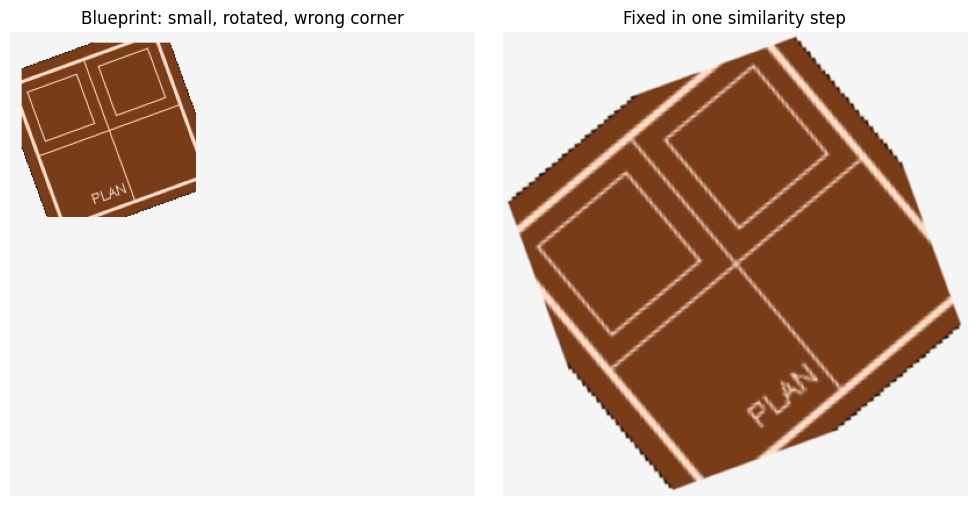

In [7]:
img = cv2.imread(f"{IMG_DIR}/task6_blueprint_misplaced.png")
h, w = img.shape[:2]

blueprint_center = np.array([85, 85])   # roughly where the small rotated plan sits
canvas_center = np.array([w / 2, h / 2])  # where we want the fixed plan centered

s = 2.2                       # scale it up to a readable size
theta = np.deg2rad(-20)       # undo the random rotation

R_scaled = s * np.array([[np.cos(theta), -np.sin(theta)],
                          [np.sin(theta),  np.cos(theta)]])

t = canvas_center - R_scaled @ blueprint_center

# --- Combine Scale + Rotation + Translation into ONE 3x3 similarity matrix ---
M_sim = np.array([[R_scaled[0, 0], R_scaled[0, 1], t[0]],
                   [R_scaled[1, 0], R_scaled[1, 1], t[1]],
                   [0,               0,              1]])
print("3x3 Similarity transformation matrix (Scale + Rotation + Translation) =\n", M_sim)

fixed_blueprint = cv2.warpAffine(img, M_sim[:2, :], (w, h), borderValue=(245, 245, 245))

show_pair(img, fixed_blueprint, "Blueprint: small, rotated, wrong corner", "Fixed in one similarity step")


## Task 7 — The Glitched Image (General Affine Transformation)

Recovered glitch matrix (original -> glitched):
 [[  0.98228663  -0.38003221  53.8647343 ]
 [  0.37037037   1.03703704 -44.44444444]]

Inverse (fix) matrix (glitched -> original):
 [[  0.89444444   0.32777778 -33.61111111]
 [ -0.31944444   0.84722222  54.86111111]]


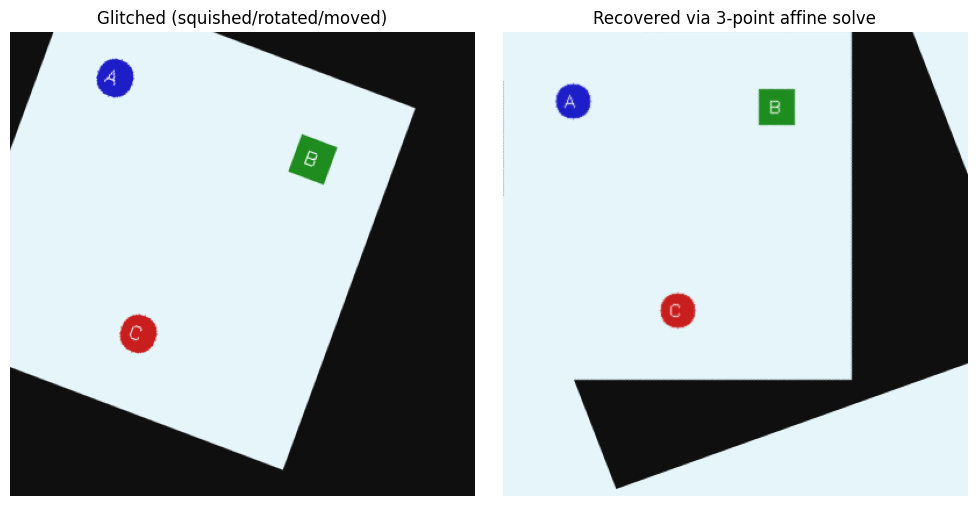

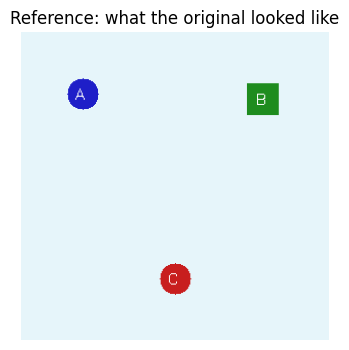

In [8]:
glitched = cv2.imread(f"{IMG_DIR}/task7_glitched_image.png")
original = cv2.imread(f"{IMG_DIR}/task7_original_reference.png")
h, w = glitched.shape[:2]

# 3 known landmark correspondences: original (clean) -> glitched (corrupted)
# Landmark A (red circle), B (green square), C (blue circle)
src = np.float32([[60, 60], [235, 65], [150, 240]])     # in the ORIGINAL photo
dst = np.float32([[90, 40], [260, 110], [110, 260]])    # where they ended up after the glitch

# --- Solve the 6-unknown system for [a b e; c d f] using the 3 point pairs ---
# Build the linear system  A @ [a,b,e,c,d,f]^T = rhs  from src -> dst
A_mat = []
rhs = []
for (x, y), (xp, yp) in zip(src, dst):
    A_mat.append([x, y, 1, 0, 0, 0]); rhs.append(xp)
    A_mat.append([0, 0, 0, x, y, 1]); rhs.append(yp)
A_mat = np.array(A_mat, dtype=np.float64)
rhs = np.array(rhs, dtype=np.float64)

a, b, e, c, d, f = np.linalg.solve(A_mat, rhs)
M_glitch = np.array([[a, b, e],
                      [c, d, f]])
print("Recovered glitch matrix (original -> glitched):\n", M_glitch)

# To FIX the image we need the INVERSE affine map (glitched -> original)
M_glitch_full = np.vstack([M_glitch, [0, 0, 1]])
M_fix_full = np.linalg.inv(M_glitch_full)
M_fix = M_fix_full[:2, :]
print("\nInverse (fix) matrix (glitched -> original):\n", M_fix)

fixed = cv2.warpAffine(glitched, M_fix, (w, h), borderValue=(250, 245, 230))

show_pair(glitched, fixed, "Glitched (squished/rotated/moved)", "Recovered via 3-point affine solve")
show(original, "Reference: what the original looked like", figsize=(4, 4))


## Task 8 — The Sidewalk Illusion (Projective · Perspective)

3x3 Perspective (homography) matrix H =
 [[ 1.76152367e+00  3.71082398e-01 -1.56467117e+02]
 [ 1.00786204e-16  1.65869361e+00 -9.34412304e-01]
 [ 4.74545166e-19  1.74364018e-03  1.00000000e+00]]


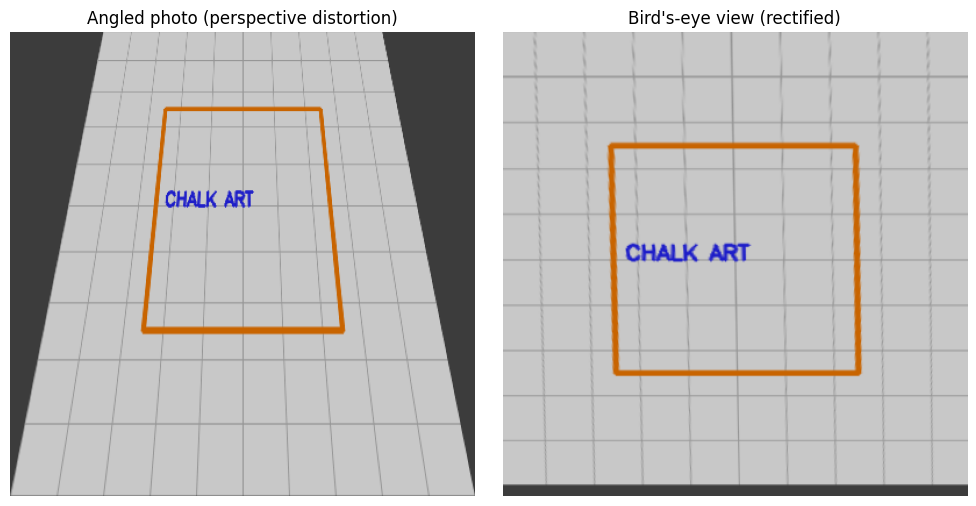

In [9]:
img = cv2.imread(f"{IMG_DIR}/task8_sidewalk_chalk_photo.png")
h, w = img.shape[:2]

# 4 corners of the chalk-art square AS THEY APPEAR in the photo
# (top edge looks narrower than bottom edge - the "far" edge)
photo_corners = np.float32([
    [138, 68],    # top-left   (far, looks pulled inward)
    [265, 68],    # top-right  (far, looks pulled inward)
    [282, 265],   # bottom-right (close)
    [116, 265],   # bottom-left  (close)
])

# Where these 4 corners SHOULD be for a perfect top-down square view
square_side = 200
top_left = (w / 2 - square_side / 2, h / 2 - square_side / 2)
target_corners = np.float32([
    [top_left[0],               top_left[1]],
    [top_left[0] + square_side, top_left[1]],
    [top_left[0] + square_side, top_left[1] + square_side],
    [top_left[0],                top_left[1] + square_side],
])

# --- Build the 3x3 perspective matrix from the 4 point correspondences ---
H = cv2.getPerspectiveTransform(photo_corners, target_corners)
print("3x3 Perspective (homography) matrix H =\n", H)

birdseye = cv2.warpPerspective(img, H, (w, h), borderValue=(60, 60, 60))

show_pair(img, birdseye, "Angled photo (perspective distortion)", "Bird's-eye view (rectified)")


## Task 9 — The Stadium Panorama (Projective · Homography)

Homography H (camera 2 -> camera 1 space) =
 [[ 1.00000000e+00  0.00000000e+00  3.20000000e+02]
 [ 0.00000000e+00  1.00000000e+00 -9.84556895e-14]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]


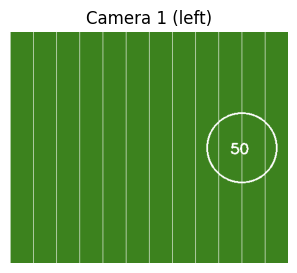

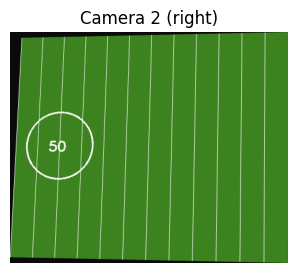

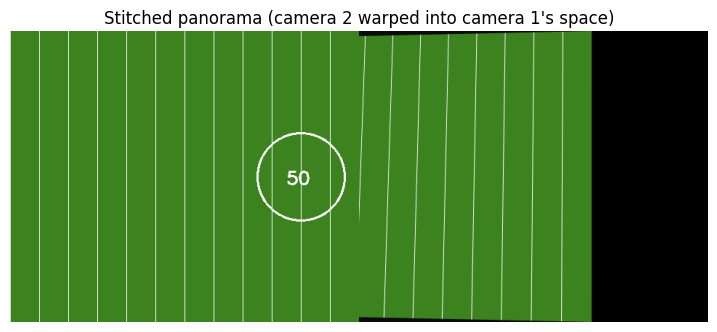

In [10]:
left = cv2.imread(f"{IMG_DIR}/task9_stadium_camera_left.png")
right = cv2.imread(f"{IMG_DIR}/task9_stadium_camera_right.png")
hl, wl = left.shape[:2]
hr, wr = right.shape[:2]

# 4 matching field-marking points, found in BOTH camera views
# (yard-line grid intersections in the overlap region)
pts_right = np.float32([[0, 0], [160, 0], [160, 400], [0, 400]])   # in camera-2's image
pts_left  = np.float32([[320, 0], [480, 0], [480, 400], [320, 400]])  # same 4 points, in camera-1's image

# --- Calculate the Homography mapping camera-2's pixels into camera-1's space ---
H, _ = cv2.findHomography(pts_right, pts_left)
print("Homography H (camera 2 -> camera 1 space) =\n", H)

# warp camera 2 into a big canvas that also contains camera 1's space
pano_w, pano_h = wl + wr, max(hl, hr)
warped_right = cv2.warpPerspective(right, H, (pano_w, pano_h))

panorama = warped_right.copy()
panorama[0:hl, 0:wl] = np.where(left == 0, panorama[0:hl, 0:wl], left)

show(left, "Camera 1 (left)", figsize=(5, 3))
show(right, "Camera 2 (right)", figsize=(5, 3))
show(panorama, "Stitched panorama (camera 2 warped into camera 1's space)", figsize=(9, 4))


## Task 10 — The Master Forger (Full Hierarchy Challenge)

Step 1 - Linear Scale matrix (factor 0.6):
[[0.6 0. ]
 [0.  0.6]]

Step 2 - Rigid transformation (translation): tx=150, ty=120

Step 3 - Projective (homography) matrix:
 [[ 1.78582523e+00  2.45772866e-01 -1.54575955e+02]
 [-3.87431767e-01  2.55753783e+00 -1.34557316e+02]
 [-3.55034838e-04  4.32698709e-05  1.00000000e+00]]


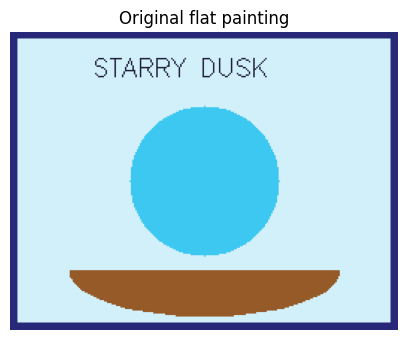

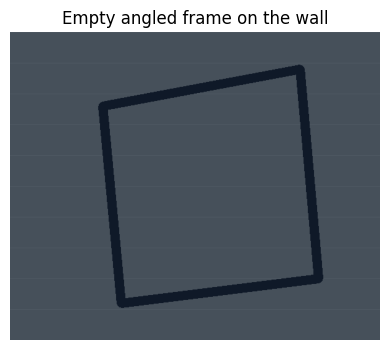

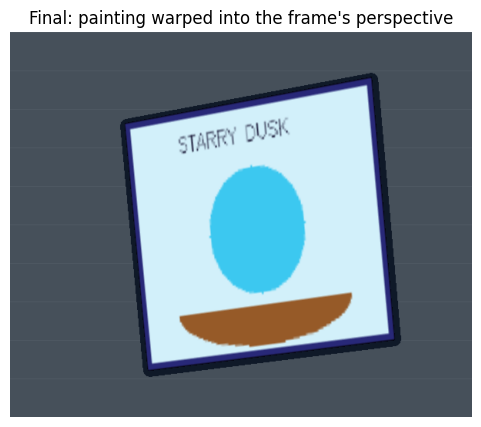

In [11]:
painting = cv2.imread(f"{IMG_DIR}/task10_painting.png")
wall = cv2.imread(f"{IMG_DIR}/task10_empty_angled_frame.png")
ph, pw = painting.shape[:2]
wh, ww = wall.shape[:2]

# --- STEP 1: Linear Scale — shrink the painting down ---
scale = 0.6
S = np.array([[scale, 0],
              [0, scale]])
scaled_w, scaled_h = int(pw * scale), int(ph * scale)
M_scale = np.hstack([S, [[0], [0]]])
scaled_painting = cv2.warpAffine(painting, M_scale, (scaled_w, scaled_h))
print(f"Step 1 - Linear Scale matrix (factor {scale}):\n{S}\n")

# --- STEP 2: Rigid Transformation — move the scaled painting near the frame ---
# (rotation = 0 here since we just need a translation onto a blank canvas
#  the same size as the wall, ready for the perspective warp)
tx, ty = 150, 120   # placeholder position near the frame's top-left corner
M_rigid = np.array([[1, 0, tx],
                     [0, 1, ty]], dtype=np.float64)
positioned = np.zeros((wh, ww, 3), dtype=np.uint8)
positioned = cv2.warpAffine(scaled_painting, M_rigid, (ww, wh))
print(f"Step 2 - Rigid transformation (translation): tx={tx}, ty={ty}\n")

# --- STEP 3: Projective Transformation — warp the painting's 4 corners ---
# into the frame's actual (angled) 4 corners on the wall
painting_corners = np.float32([
    [tx, ty], [tx + scaled_w, ty],
    [tx + scaled_w, ty + scaled_h], [tx, ty + scaled_h],
])
# these are the frame's real corners on the wall (from the polylines drawn in generate_images.py)
frame_corners = np.float32([[150, 120], [470, 60], [500, 400], [180, 440]])

H = cv2.getPerspectiveTransform(painting_corners, frame_corners)
print("Step 3 - Projective (homography) matrix:\n", H)

warped_painting = cv2.warpPerspective(positioned, H, (ww, wh))

# composite: paste the warped painting onto the wall wherever it's non-black
mask = (warped_painting.sum(axis=2) > 15)
forged = wall.copy()
forged[mask] = warped_painting[mask]

show(painting, "Original flat painting", figsize=(5, 4))
show(wall, "Empty angled frame on the wall", figsize=(5, 4))
show(forged, "Final: painting warped into the frame's perspective", figsize=(6, 5))
